In [11]:
# load
import pandas as pd

df = pd.read_csv('../data/raw/AAPL_prices.csv', parse_dates=['Date'], index_col='Date')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df = df.dropna()

print(df.head())

# normalise
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

             Open   High    Low  Close   Volume
Date                                           
1999-11-01  80.00  80.69  77.37  77.62  2487300
1999-11-02  78.00  81.69  77.31  80.25  3564600
1999-11-03  81.62  83.25  81.00  81.50  2932700
1999-11-04  82.06  85.37  80.62  83.62  3384700
1999-11-05  84.62  88.37  84.00  88.31  3721500


In [12]:
len(scaled_data)

6453

In [13]:
import numpy as np

def create_sequences(data, window):
    X, y = [], []
    for i in range (window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i, 3])  # Close price is at index 3
    return np.array(X), np.array(y)

window_size = 60
X, y = create_sequences(scaled_data, window_size)

In [14]:
import torch.nn as nn

class SimpleLSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=5, hidden_size=64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [15]:
import torch
from torch.utils.data import DataLoader, Dataset

# Define split index (e.g., 80% for training)
split_ratio = 0.8
split_index = int(len(X) * split_ratio)

# Split sequences and labels
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

# Dataset class
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Dataloader
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Model, loss, optimizer
model = SimpleLSTMModel()
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []

# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_X)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            output = model(batch_X)
            loss = criterion(output, batch_y)
            val_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")




Epoch 1/100 | Train Loss: 0.013598 | Val Loss: 0.004670
Epoch 2/100 | Train Loss: 0.010612 | Val Loss: 0.002211
Epoch 3/100 | Train Loss: 0.003677 | Val Loss: 0.002307
Epoch 4/100 | Train Loss: 0.000714 | Val Loss: 0.001348
Epoch 5/100 | Train Loss: 0.000542 | Val Loss: 0.000604
Epoch 6/100 | Train Loss: 0.000650 | Val Loss: 0.001061
Epoch 7/100 | Train Loss: 0.000589 | Val Loss: 0.001316
Epoch 8/100 | Train Loss: 0.000596 | Val Loss: 0.001769
Epoch 9/100 | Train Loss: 0.000598 | Val Loss: 0.002138
Epoch 10/100 | Train Loss: 0.000595 | Val Loss: 0.002388
Epoch 11/100 | Train Loss: 0.000582 | Val Loss: 0.002497
Epoch 12/100 | Train Loss: 0.000565 | Val Loss: 0.002550
Epoch 13/100 | Train Loss: 0.000551 | Val Loss: 0.002616
Epoch 14/100 | Train Loss: 0.000540 | Val Loss: 0.002704
Epoch 15/100 | Train Loss: 0.000532 | Val Loss: 0.002802
Epoch 16/100 | Train Loss: 0.000525 | Val Loss: 0.002896
Epoch 17/100 | Train Loss: 0.000517 | Val Loss: 0.002977
Epoch 18/100 | Train Loss: 0.000509 | Va

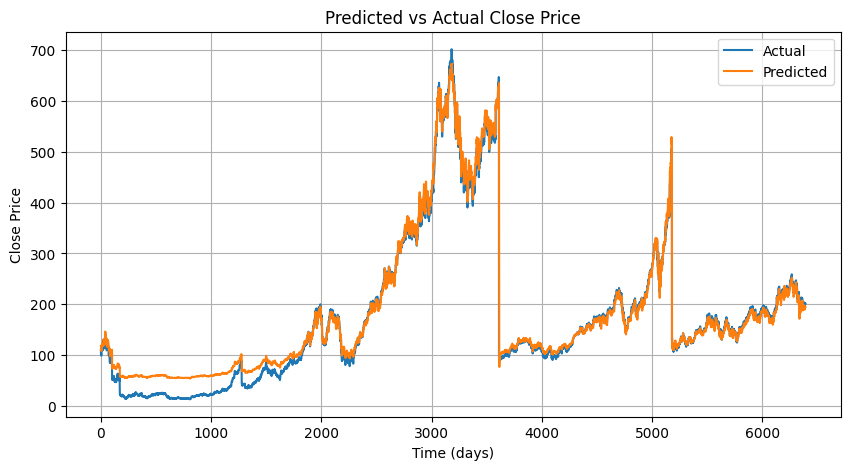

In [16]:
import matplotlib.pyplot as plt
model.eval()

# Predict on all data
with torch.no_grad():
    all_preds = model(torch.tensor(X, dtype=torch.float32)).numpy()

# Restore Close prices (index 3) in scaled data to predicted values
scaled_pred = scaled_data[window_size:].copy()
scaled_pred[:, 3] = all_preds.flatten()

# Inverse transform all features
inverted = scaler.inverse_transform(scaled_pred)
predicted_close = inverted[:, 3]

# Actual Close prices
actual_close = df["Close"].values[window_size:]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(actual_close, label='Actual')
plt.plot(predicted_close, label='Predicted')
plt.xlabel("Time (days)")
plt.ylabel("Close Price")
plt.title("Predicted vs Actual Close Price")
plt.legend()
plt.grid(True)
plt.show()


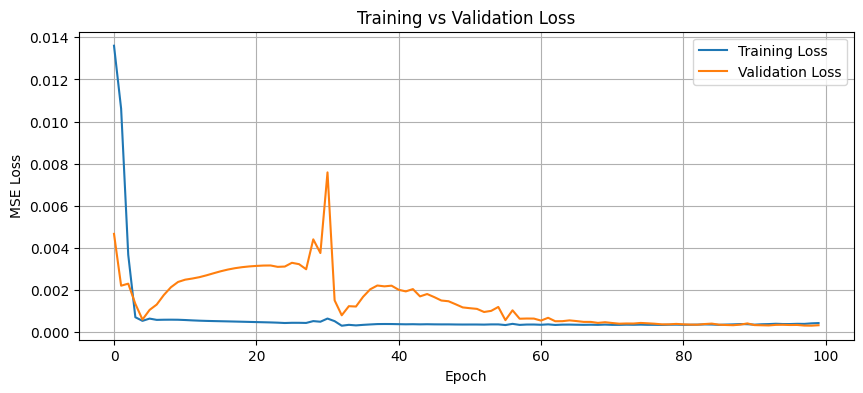

In [17]:
# Loss Curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


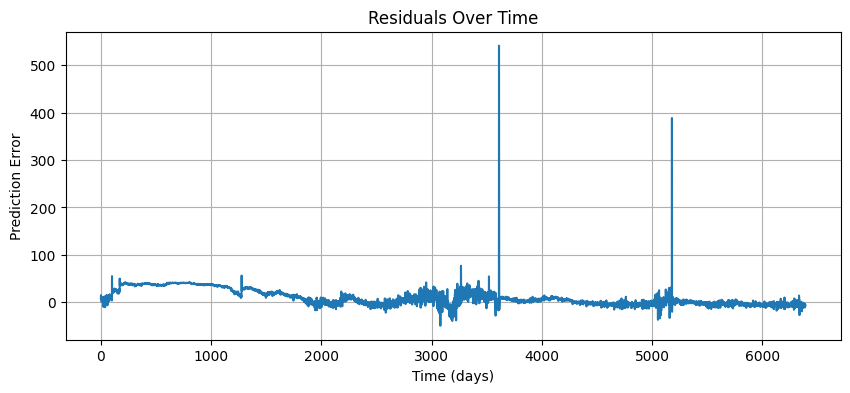

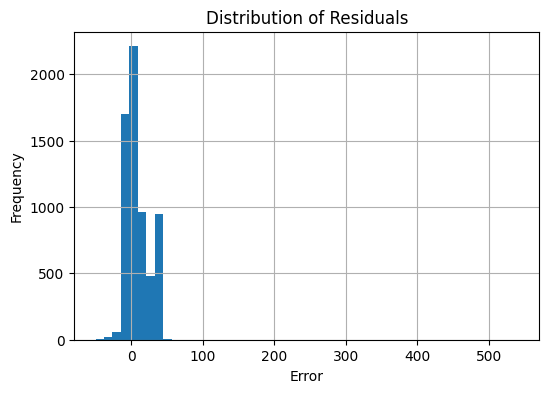

In [18]:
# Residuals Analysis
residuals = predicted_close - actual_close

plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.xlabel("Time (days)")
plt.ylabel("Prediction Error")
plt.title("Residuals Over Time")
plt.grid(True)
plt.show()

# Optionally, histogram
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=50)
plt.title("Distribution of Residuals")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


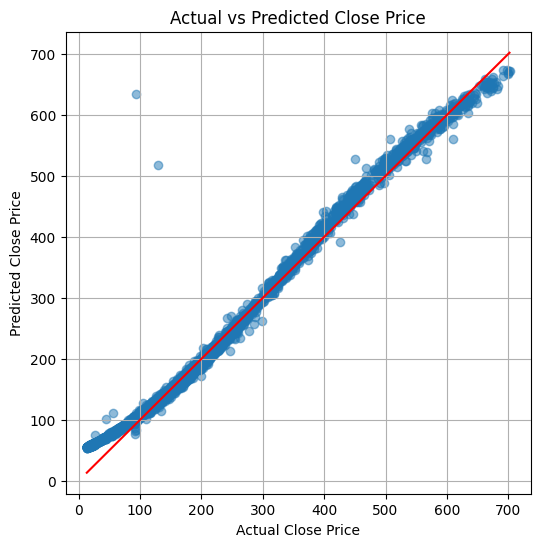

In [19]:
# Scatter Plot
plt.figure(figsize=(6, 6))
plt.scatter(actual_close, predicted_close, alpha=0.5)
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Actual vs Predicted Close Price")
plt.grid(True)
plt.plot([min(actual_close), max(actual_close)], [min(actual_close), max(actual_close)], color='red')  # ideal line
plt.show()


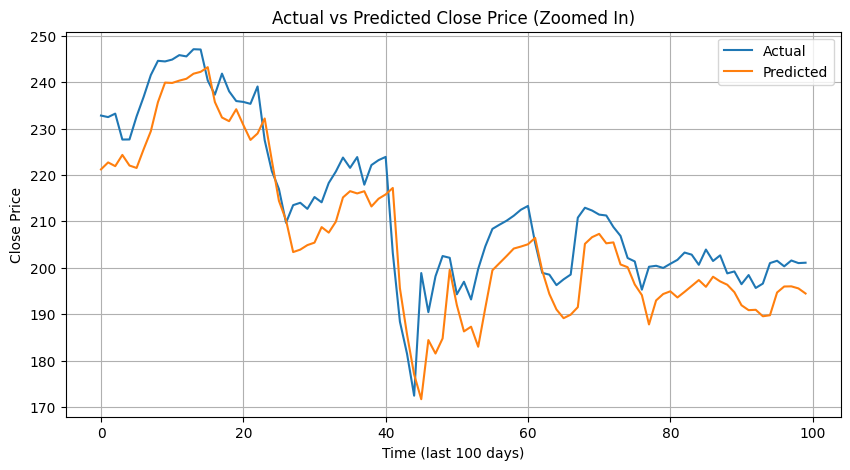

In [20]:
# Zoomed In Plot
plt.figure(figsize=(10, 5))
plt.plot(actual_close[-100:], label='Actual')
plt.plot(predicted_close[-100:], label='Predicted')
plt.xlabel("Time (last 100 days)")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Close Price (Zoomed In)")
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# correlation coefficient
from scipy.stats import pearsonr

corr, _ = pearsonr(actual_close, predicted_close)
print(f"Pearson Correlation: {corr:.4f}")


Pearson Correlation: 0.9931


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual_close, predicted_close))
mae = mean_absolute_error(actual_close, predicted_close)
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")


RMSE: 19.98, MAE: 13.11
